In [ ]:
# ! pip install glasbey

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import glasbey

In [4]:
filename = r'Y:\Members\Mia-Sanjana-Hadent\Processed Data\042425_2lc\week8-10-12-14-18\combined_matrix_2lc.csv'
data = pd.read_csv( filename , index_col=0)

data

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,...,Feature24,Feature25,Feature26,Feature27,Feature28,Feature29,Feature30,Timestamp,Cluster,Week_Number
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.500000,0.500000,0.000000,0.0,0.866667,0.133333,8414.3922,1,8
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.383333,0.616667,0.000000,0.0,0.733333,0.266667,8414.6932,1,8
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.516667,0.483333,0.000000,0.0,0.883333,0.116667,8414.9927,1,8
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.600000,0.400000,0.000000,0.0,0.916667,0.083333,8415.2930,1,8
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.116667,0.566667,0.166667,0.000000,0.0,0.466667,0.533333,8415.5933,1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120975,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.083333,0.483333,0.416667,0.016667,0.0,0.066667,0.933333,49786.8398,27,18
120976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.066667,0.350000,0.400000,0.183333,0.0,0.000000,1.000000,49787.2048,27,18
120977,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.6,0.4,...,0.033333,0.483333,0.250000,0.133333,0.0,0.000000,1.000000,49787.5498,87,18
120978,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.183333,0.150000,0.333333,0.216667,0.0,0.000000,1.000000,49787.8948,50,18


In [ ]:
# Automatically find the number of stages
weeks = data['Week_Number'].unique()
stage_names = [f"Stage {i}" for i in range(1, len(weeks) + 1)]

# Automatically find the total number of clusters
num_clusters = data['Cluster'].max()

# Get all clusters present across the ENTIRE dataset
all_clusters = sorted(data['Cluster'].unique())
cluster_labels_str = [str(c) for c in all_clusters]

# Create color pallette
glasbey_palette = glasbey.create_palette(palette_size=num_clusters)
cluster_to_color = {
    str(c): glasbey_palette[i % num_clusters]
    for i, c in enumerate(all_clusters)
}

In [12]:
# --- Define features for PCA ---
feature_cols = [f"Feature{i}" for i in range(1, 31)]  
X = data[feature_cols].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
data['PCA1'] = pca_result[:, 0]
data['PCA2'] = pca_result[:, 1]

# --- Map cluster colors using your Glasbey palette ---
# Make sure the cluster column is string to match your mapping
data['cluster_str'] = data['Cluster'].astype(str)
data['color'] = data['cluster_str'].map(cluster_to_color)

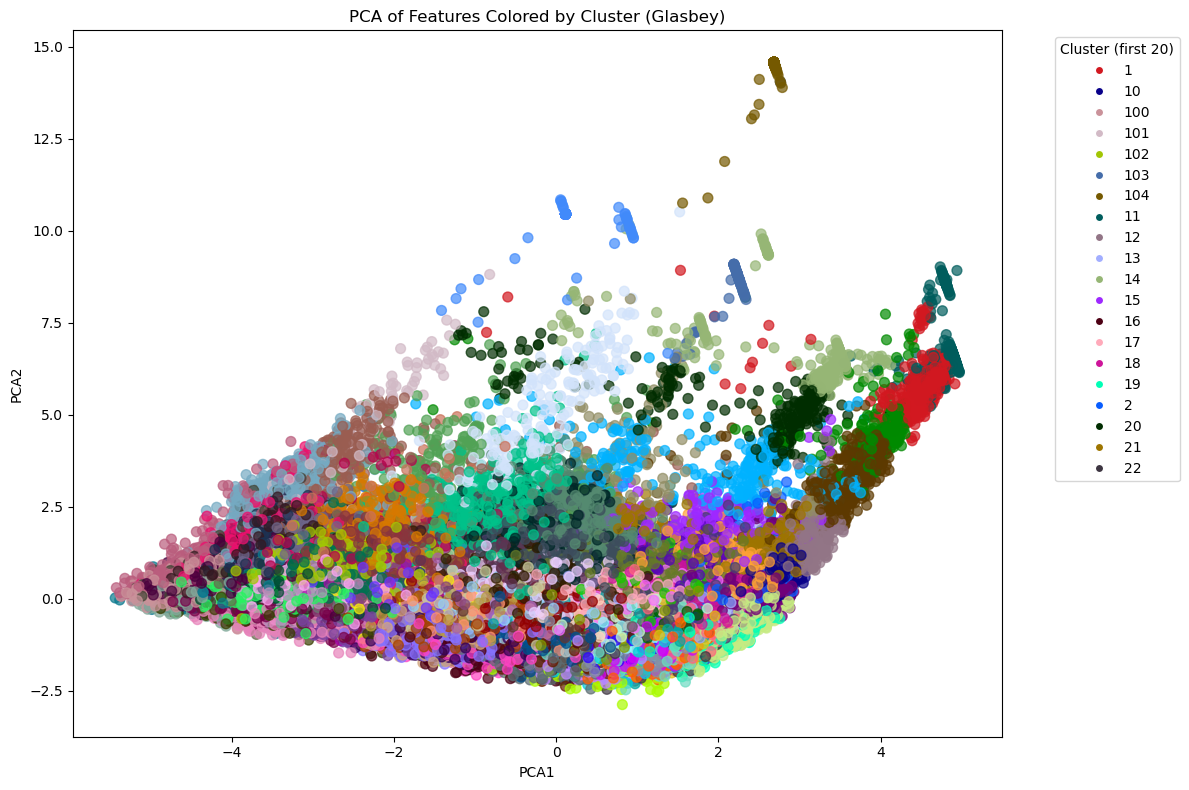

In [ ]:
# --- Plot PCA ---
plt.figure(figsize=(12, 8))
plt.scatter(
    data['PCA1'],
    data['PCA2'],
    c=data['color'],
    s=50,
    alpha=0.7
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("PCA of Features Colored by Cluster (Glasbey)")

# Legend (showing first 20 clusters for readability)
unique_clusters = sorted(data['cluster_str'].unique())
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_to_color[c], markersize=6)
    for c in unique_clusters[:20]
]
labels = unique_clusters[:20]
plt.legend(handles, labels, title="Cluster (first 20)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()